# Claude Model Usage for Healthcare AI Researchers

---

### Agenda
1. **Prompting Claude: Simple to Complex** — API basics, system prompts, multi-turn, thinking, tools, structured outputs
2. **VS Code Extension & Claude Code CLI** — IDE integration, slash commands, agentic coding
3. **Advanced Healthcare Research Usage** — Batch processing, RAG, Citations, HIPAA

---
*Prerequisites: Python 3.9+, `pip install anthropic`*

# Part 1: Prompting Claude — Simple to Complex

---

### Claude Model Family (2026) - Choose the right model!

| Model | ID | Context | Input $/1M | Output $/1M | Best For |
|---|---|---|---|---|---|
| Fable 5 | `claude-fable-5` | 1M | $10 | $50 | Frontier reasoning |
| **Opus 4.8** | `claude-opus-4-8` | 1M | $5 | $25 | **Default: complex research** |
| Sonnet 4.6 | `claude-sonnet-4-6` | 1M | $3 | $15 | Balanced speed/quality |
| Haiku 4.5 | `claude-haiku-4-5` | 200K | $1 | $5 | High-throughput classification |

> **Rule of thumb**: Start with Opus 4.8 for research. Use Haiku for batch classification tasks.

In [26]:
pip install Display -U -q


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [8]:
# Setup — run once per session
import anthropic
import os, json, pickle
from dotenv import load_dotenv

from IPython.display import display, Markdown

In [24]:

# Keep the API key in .env file and load it into the system environment
load_dotenv()

ANTHROPIC_API_KEY = os.environ.get("ANTHROPIC_API_KEY") # it needs a paid account to work.

In [25]:
ANTHROPIC_API_KEY[:20]

'sk-ant-api03-sxJMhWM'

In [28]:
# initialize the client with the API key from environment variable
client = anthropic.Anthropic()  # reads ANTHROPIC_API_KEY from environment

if client:
    display(Markdown("**Anthropic client initialized successfully.**"))
#print("Anthropic SDK version:", anthropic.__version__)

**Anthropic client initialized successfully.**

# common issues of API call
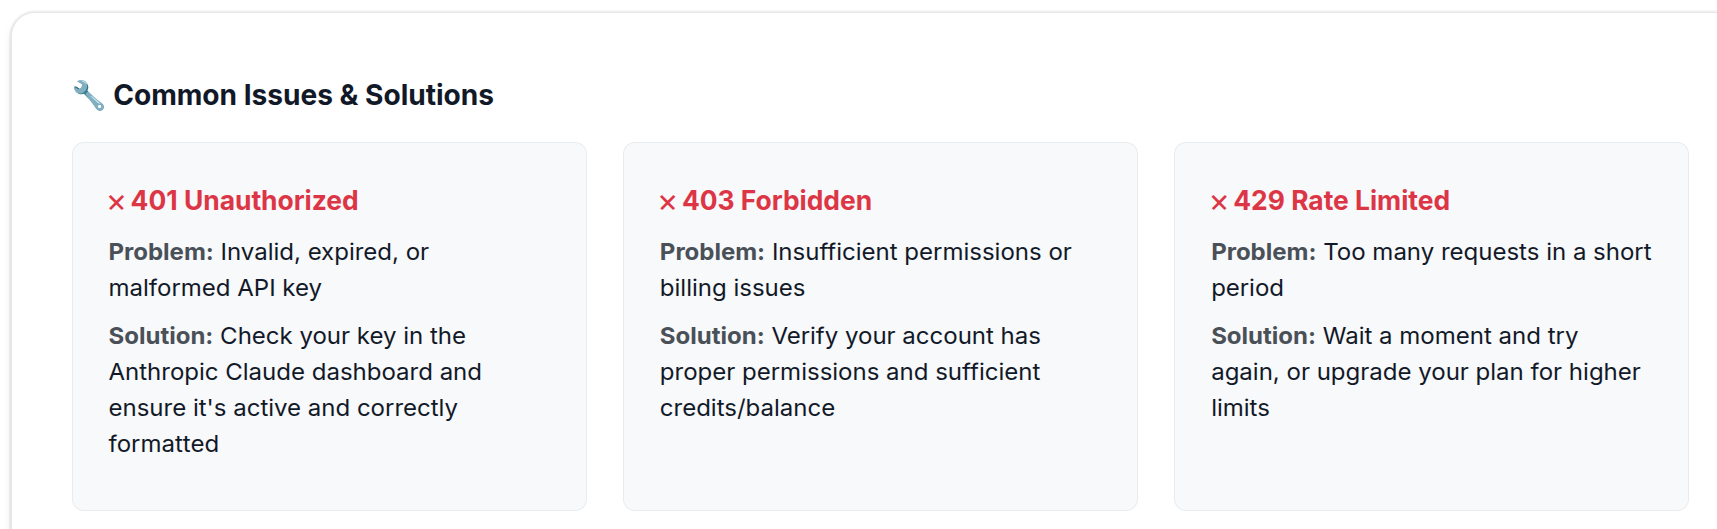

## 1.1 — The Simplest Possible Request

Three required fields:
- `model` — which Claude model
- `max_tokens` — output budget (not a target, a ceiling)
- `messages` — list of `{role, content}` dicts

```python
response = client.messages.create(
    model="claude-opus-4-8",
    max_tokens=1024,
    messages=[{"role": "user", "content": "What is pharmacovigilance?"}]
)
print(response.content[0].text)
```

In [21]:
# # 1.1 — Simple one-shot call
# response = client.messages.create(
#     model="claude-opus-4-8",
#     max_tokens=512,
#     messages=[
#         {"role": "user", "content": "What is pharmacovigilance? Give a 2-sentence definition."}
#     ]
# )

# print(response.content[0].text)
# print(f"\n--- Token usage ---")
# print(f"Input:  {response.usage.input_tokens} tokens")
# print(f"Output: {response.usage.output_tokens} tokens")

In [10]:
display(Markdown("Pharmacovigilance is the science and activities related to the detection, assessment, understanding, and prevention of adverse effects or any other drug-related problems. It encompasses the systematic collection and analysis of safety data from spontaneous reports, clinical trials, and real-world databases — such as FDA FAERS — to ensure that the benefits of medicines continue to outweigh their risks throughout their lifecycle."))

Pharmacovigilance is the science and activities related to the detection, assessment, understanding, and prevention of adverse effects or any other drug-related problems. It encompasses the systematic collection and analysis of safety data from spontaneous reports, clinical trials, and real-world databases — such as FDA FAERS — to ensure that the benefits of medicines continue to outweigh their risks throughout their lifecycle.

## 1.2 — System Prompts: Setting Persona & Context

The `system` parameter sets persistent instructions Claude follows throughout the conversation.

**Good system prompts:**
- Define the AI's role and expertise
- Specify output format preferences
- Set domain constraints
- Establish tone and vocabulary

```python
response = client.messages.create(
    model="claude-opus-4-8",
    max_tokens=1024,
    system="You are an expert pharmacovigilance scientist. Always cite MedDRA terminology.",
    messages=[{"role": "user", "content": "..."}]
)
```

In [11]:
# # 1.2 — System prompt example
# PHARMACOVIGILANCE_SYSTEM = """You are an expert pharmacovigilance scientist with deep knowledge of:
# - FDA Adverse Event Reporting System (FAERS)
# - MedDRA terminology (SOC, HLGT, HLT, PT hierarchy)
# - Drug safety signal detection methods
# - ICH E2B guidelines

# When discussing adverse events, always use MedDRA Preferred Terms (PT).
# Be concise and precise. Use medical terminology."""

# response = client.messages.create(
#     model="claude-opus-4-8",
#     max_tokens=512,
#     system=PHARMACOVIGILANCE_SYSTEM,
#     messages=[
#         {"role": "user", "content": "What are the main cardiac adverse events associated with azithromycin?"}
#     ]
# )

# print(response.content[0].text) # output in json format

In [14]:
display(Markdown('''Azithromycin's main cardiac adverse events, by MedDRA Preferred Term:

MedDRA PT	Mechanism	Risk Level
QT interval prolongation (PT: 10037142)	hERG potassium channel blockade	Most common; dose-dependent
Torsade de Pointes (PT: 10044243)	Secondary to QT prolongation	Rare but life-threatening
Ventricular tachycardia (PT: 10047281)	Triggered arrhythmia	Rare
Ventricular fibrillation (PT: 10047302)	Severe arrhythmia	Very rare
Cardiac arrest (PT: 10007515)	End-stage arrhythmia cascade	Very rare
Palpitations (PT: 10033557)	Electrophysiologic disturbance	Uncommon
MedDRA SOC: Cardiac disorders (10007541)

Key risk factors for cardiac ADRs:

Baseline QTc > 450ms
Concurrent QT-prolonging drugs (fluoroquinolones, antipsychotics, ondansetron)
Hypokalemia / hypomagnesemia
Elderly patients, female sex
Known structural heart disease
Regulatory context: FDA issued a Drug Safety Communication in 2013 warning about azithromycin's potential to cause abnormal heart rhythms, particularly fatal arrhythmias — leading to label updates across all formulations.'''))

Azithromycin's main cardiac adverse events, by MedDRA Preferred Term:

MedDRA PT	Mechanism	Risk Level
QT interval prolongation (PT: 10037142)	hERG potassium channel blockade	Most common; dose-dependent
Torsade de Pointes (PT: 10044243)	Secondary to QT prolongation	Rare but life-threatening
Ventricular tachycardia (PT: 10047281)	Triggered arrhythmia	Rare
Ventricular fibrillation (PT: 10047302)	Severe arrhythmia	Very rare
Cardiac arrest (PT: 10007515)	End-stage arrhythmia cascade	Very rare
Palpitations (PT: 10033557)	Electrophysiologic disturbance	Uncommon
MedDRA SOC: Cardiac disorders (10007541)

Key risk factors for cardiac ADRs:

Baseline QTc > 450ms
Concurrent QT-prolonging drugs (fluoroquinolones, antipsychotics, ondansetron)
Hypokalemia / hypomagnesemia
Elderly patients, female sex
Known structural heart disease
Regulatory context: FDA issued a Drug Safety Communication in 2013 warning about azithromycin's potential to cause abnormal heart rhythms, particularly fatal arrhythmias — leading to label updates across all formulations.

In [17]:
import pandas as pd
medDRA_PT = pd.read_clipboard()

In [18]:
medDRA_PT

,MedDRA PT,Mechanism,Risk Level
0,QT interval prolongation (PT: 10037142),hERG potassium channel blockade,Most common; dose-dependent
1,Torsade de Pointes (PT: 10044243),Secondary to QT prolongation,Rare but life-threatening
2,Ventricular tachycardia (PT: 10047281),Triggered arrhythmia,Rare
3,Ventricular fibrillation (PT: 10047302),Severe arrhythmia,Very rare
4,Cardiac arrest (PT: 10007515),End-stage arrhythmia cascade,Very rare
5,Palpitations (PT: 10033557),Electrophysiologic disturbance,Uncommon


## 1.3 — Multi-Turn Conversations

Claude's API is **stateless**
 - you have to send the full conversation history for next call, unlike Openclaw. 
 - Claude charges roundtrip, input and output tokens. 

```
Turn 1: [user_msg_1]                  → assistant_reply_1
Turn 2: [user_msg_1, reply_1, user_msg_2]  → assistant_reply_2
Turn 3: [user_msg_1, reply_1, ..., user_msg_3] → assistant_reply_3
```

**Key pattern:** Maintain a `history` list; append each exchange.

> **Cost insight:** Each turn re-sends the entire history. Use **prompt caching** to save up to 90% on repeated context (shown later).

In [19]:
# # 1.3 — Multi-turn conversation helper
# def chat(history, user_message, system=None, model="claude-opus-4-8", max_tokens=512):
#     """Send one turn; return (assistant_text, updated_history)."""
#     history = history + [{"role": "user", "content": user_message}]
#     kwargs = {"model": model, "max_tokens": max_tokens, "messages": history}
#     if system:
#         kwargs["system"] = system
#     response = client.messages.create(**kwargs)
#     reply = response.content[0].text
#     history = history + [{"role": "assistant", "content": reply}]
#     return reply, history

# # Simulate a multi-turn research conversation
# history = []

# reply, history = chat(history, "What MedDRA SOC covers cardiovascular adverse events?",
#                       system=PHARMACOVIGILANCE_SYSTEM)
# print("Turn 1:", reply[:200], "...\n")

# reply, history = chat(history, "List 5 important PT codes within that SOC.")
# print("Turn 2:", reply[:300], "...\n")

# reply, history = chat(history, "Which of those are most commonly reported in FAERS for statins?")
# print("Turn 3:", reply[:300])

# print(f"\nConversation turns: {len(history)//2}")

## 1.4 — Streaming for Long Outputs - have fun!

Use streaming when:
- Generating long documents or reports
- Building interactive UIs
- Avoiding request timeouts (common for `max_tokens > 4000`)

```python
with client.messages.stream(...) as stream:
    for text in stream.text_stream:
        print(text, end="", flush=True)
```

`.get_final_message()` gives you the complete response object after the stream ends.

In [ ]:
# 1.4 — Streaming response
print("Streaming response:\n" + "-"*40)

with client.messages.stream(
    model="claude-opus-4-8",
    max_tokens=512,
    system=PHARMACOVIGILANCE_SYSTEM,
    messages=[{
        "role": "user",
        "content": "Write a brief summary of disproportionality analysis methods in pharmacovigilance (PRR, ROR, BCPNN)."
    }]
) as stream:
    for text in stream.text_stream:
        # streaming output as it arrives
        print(text, end="", flush=True)

final = stream.get_final_message()
print(f"\n\nTotal output tokens: {final.usage.output_tokens}")

# To avoid error due to unrecognized "\c" in markdown string, use a raw string

In [23]:
display(Markdown(r'''Disproportionality analysis detects drug safety signals by comparing whether a drug-event pair is reported more than expected relative to all drugs and all events in a spontaneous reporting database (e.g., FAERS).

Core Methods
PRR — Proportional Reporting Ratio
$$PRR = \frac{a/(a+b)}{c/(c+d)}$$

Where a = reports of drug+event, b = drug without event, c = other drugs with event, d = all others.

Signal threshold: PRR ≥ 2, χ² ≥ 4, and n ≥ 3
Used by: EMA/MHRA
Limitation: Unstable with small counts; no uncertainty quantification
ROR — Reporting Odds Ratio
$$ROR = \frac{a \cdot d}{b \cdot c}$$

Analogous to odds ratio in case-control studies
Signal threshold: Lower bound of 95% CI > 1
Used by: WHO VigiBase, Netherlands Pharmacovigilance Centre
Limitation: Inflated in small databases; same 2×2 table dependency as PRR
BCPNN — Bayesian Confidence Propagation Neural Network
$$IC = \log_2 \frac{P(drug, event)}{P(drug) \cdot P(event)}$$

IC > 0 indicates positive association (reports more than expected under independence)
Signal when IC025 (lower 95\% credible interval) > 0
Used by: WHO Uppsala Monitoring Centre (VigiBase)
Strength: Shrinks estimates toward zero for rare counts — stable with sparse data'''))

Disproportionality analysis detects drug safety signals by comparing whether a drug-event pair is reported more than expected relative to all drugs and all events in a spontaneous reporting database (e.g., FAERS).

Core Methods
PRR — Proportional Reporting Ratio
$$PRR = \frac{a/(a+b)}{c/(c+d)}$$

Where a = reports of drug+event, b = drug without event, c = other drugs with event, d = all others.

Signal threshold: PRR ≥ 2, χ² ≥ 4, and n ≥ 3
Used by: EMA/MHRA
Limitation: Unstable with small counts; no uncertainty quantification
ROR — Reporting Odds Ratio
$$ROR = \frac{a \cdot d}{b \cdot c}$$

Analogous to odds ratio in case-control studies
Signal threshold: Lower bound of 95% CI > 1
Used by: WHO VigiBase, Netherlands Pharmacovigilance Centre
Limitation: Inflated in small databases; same 2×2 table dependency as PRR
BCPNN — Bayesian Confidence Propagation Neural Network
$$IC = \log_2 \frac{P(drug, event)}{P(drug) \cdot P(event)}$$

IC > 0 indicates positive association (reports more than expected under independence)
Signal when IC025 (lower 95\% credible interval) > 0
Used by: WHO Uppsala Monitoring Centre (VigiBase)
Strength: Shrinks estimates toward zero for rare counts — stable with sparse data

## 1.5 — Adaptive Thinking (Extended Reasoning)

Gives Claude a **private reasoning instruction** before responding.

| Setting | When to use |
|---|---|
| `effort: "low"` | Fast classification, simple extraction |
| `effort: "medium"` | Default — general reasoning tasks |
| `effort: "high"` | Complex multi-step reasoning |
| `effort: "xhigh"` | Hardest research questions, novel analysis |
| `effort: "max"` | Maximum reasoning (highest cost) |

**Key insight**: For complex question requiring multi-hop reasoning, use `effort: "high"` (default) or `"xhigh"`. Or use "low" (/fast in chatbot) 

In [ ]:
# 1.5 — Adaptive thinking with effort level
response = client.messages.create(
    model="claude-opus-4-8",
    max_tokens=8000, #control token budget for reasoning depth
    thinking={"type": "adaptive", "display": "summarized"},
    output_config={"effort": "high"}, # control the depth of reasoning, default
    system=PHARMACOVIGILANCE_SYSTEM,
    messages=[{
        "role": "user",
        "content": """
        A patient is on metformin (T2DM), atorvastatin (dyslipidemia), and lisinopril (HTN).
        They report muscle weakness and dark urine.
        
        Reason through which drug(s) are most likely responsible, considering:
        1. Known ADR profiles of each drug
        2. Drug-drug interaction potential
        3. MedDRA PT codes for the reported symptoms
        4. Recommended next steps for the clinician
        """
    }]
)

# The response may include a thinking block followed by the answer
for block in response.content:
    if block.type == "thinking":
        # partially show the reasoning summary (first 500 characters) to avoid overwhelming output
        print("[REASONING SUMMARY]")
        print(block.thinking[:500] if block.thinking else "(omitted)")
        print()
    elif block.type == "text":
        # display the final answer text
        print("[ANSWER]")
        print(block.text)

## 1.6 — Tool Use

Claude can call your functions by describing them in JSON Schema.

**Two modes:**
1. **Manual loop** — you detect `tool_use` stop reason, call the function, send back `tool_result`
2. **SDK Tool Runner** — decorator-based, handles the loop automatically

```
Request → Claude decides to call tool → Your code executes function
         ← Send tool result back ←     → Claude continues with result
```

**Server-side tools** (no code needed on your end):
- `web_search` — real-time web search
- `code_execution` — Python sandbox
- `computer_use` — desktop automation

In [29]:
from IPython.display import display, Markdown

display(Markdown("""
```mermaid
flowchart LR
    A([Request]) --> B[Claude decides\\nto call tool]
    B --> C[Your code\\nexecutes function]
    C --> D[Send tool\\nresult back]
    D --> E{Claude continues}
    E -->|another tool call| B
    E -->|done| F([Final Response])
```
"""))


```mermaid
flowchart LR
    A([Request]) --> B[Claude decides\nto call tool]
    B --> C[Your code\nexecutes function]
    C --> D[Send tool\nresult back]
    D --> E{Claude continues}
    E -->|another tool call| B
    E -->|done| F([Final Response])
```


### 1.6a — Manual tool use loop, 
 - Using the OpenFDA API — free, no key needed, returns real FAERS data

In [40]:
import json, requests
from types import SimpleNamespace
from utils.func import get_faers_count

# --- 1. define tool ---
tools = [{
    "name": "get_faers_count",
    "description": "Look up real FAERS adverse event report count for a drug via OpenFDA",
    "input_schema": {
        "type": "object",
        "properties": {
            "drug": {"type": "string", "description": "Drug name, e.g. metformin"}
        },
        "required": ["drug"]
    }
}]

# --- 2. simulate the Claude response that requests a tool call ---
tool_block = SimpleNamespace(
    type="tool_use",
    id="tool_use_demo_001",
    name="get_faers_count",
    input={"drug": "semaglutide"}
)
response = SimpleNamespace(
    stop_reason="tool_use",
    content=[tool_block]
)

# --- 3. tool dispatch (identical to real loop)
tool   = next(b for b in response.content if b.type == "tool_use")
result = get_faers_count(**tool.input)          # hits real OpenFDA
print(f"[tool] {tool.input} → {result}")

messages = []
messages.append({"role": "assistant", "content": response.content})
messages.append({
    "role": "user",
    "content": [{
        "type": "tool_result",
        "tool_use_id": tool.id,
        "content": json.dumps(result)
    }]
})

print("\nmessages ready to send back to Claude:")
print(json.dumps(messages, indent=2, default=str))

[tool] {'drug': 'semaglutide'} → {'drug': 'semaglutide', 'faers_reports': 6618}

messages ready to send back to Claude:
[
  {
    "role": "assistant",
    "content": [
      "namespace(type='tool_use', id='tool_use_demo_001', name='get_faers_count', input={'drug': 'semaglutide'})"
    ]
  },
  {
    "role": "user",
    "content": [
      {
        "type": "tool_result",
        "tool_use_id": "tool_use_demo_001",
        "content": "{\"drug\": \"semaglutide\", \"faers_reports\": 6618}"
      }
    ]
  }
]


## 1.7 — Structured Outputs (JSON Schema)

Force Claude to return valid, schema-conforming JSON — ideal for:
- Extracting entities from clinical text
- Building downstream data pipelines
- Classification with confidence scores

Two approaches:
1. **`output_config.format`** — built-in schema enforcement
2. **`client.messages.parse()`** — validates + auto-parses response

> No more regex hacks on JSON output!

In [42]:
# 1.7 — Structured output: extract drug query information from FAERS DB
from IPython.display import display, Markdown

for msg in messages:
    role = msg["role"].upper()
    content = msg["content"]

    if isinstance(content, list):
        for block in content:
            if hasattr(block, "type"):                        # SimpleNamespace block
                display(Markdown(f"**[{role} · {block.type}]** `id={block.id}`  \ninput: `{block.input}`"))
            elif isinstance(block, dict):                     # tool_result dict
                display(Markdown(f"**[{role} · tool_result]** `id={block['tool_use_id']}`  \n```json\n{block['content']}\n```"))
    else:
        display(Markdown(f"**[{role}]** {content}"))

**[ASSISTANT · tool_use]** `id=tool_use_demo_001`  
input: `{'drug': 'semaglutide'}`

**[USER · tool_result]** `id=tool_use_demo_001`  
```json
{"drug": "semaglutide", "faers_reports": 6618}
```

## 1.8 — Prompt Caching (Cost Optimization)

When the same large context is reused across many calls, cache it.

**Up to 90% cost savings** on cached tokens.

| Request type | Cost multiplier |
|---|---|
| Cache write | 1.25× normal |
| Cache read | 0.10× normal (90% off!) |

**Use case**: System prompt with 10,000-token drug knowledge base, queried 1,000 times:
- Without caching: 10M input tokens × $5 = **$50**
- With caching: 1 write + 999 reads ≈ **$5.50** (89% savings)

In [ ]:
# 1.8 — Prompt caching: cache a large drug knowledge base
DRUG_KNOWLEDGE_BASE = """
# Drug Safety Knowledge Base

## Statins (HMG-CoA Reductase Inhibitors)
Key ADRs: Myopathy, rhabdomyolysis, elevated liver enzymes, headache
Mechanism: Inhibits cholesterol synthesis, may affect CoQ10 levels in muscle
Risk factors: High dose, renal impairment, CYP3A4 inhibitors (for some statins)
Monitoring: CK levels, LFTs at baseline and periodically
Signal threshold (PRR): myopathy PRR >2 considered signal

## ACE Inhibitors
Key ADRs: Dry cough (10-15% incidence), angioedema (0.1-0.7%), hyperkalemia
Mechanism: Bradykinin accumulation → cough; may precipitate angioedema
Contraindications: Bilateral renal artery stenosis, pregnancy
MedDRA PT codes: Cough (10011224), Angioedema (10002424), Hyperkalaemia (10020647)

## Fluoroquinolones
Key ADRs: Tendinopathy, tendon rupture (Achilles), QT prolongation, peripheral neuropathy
Black box warnings: Tendon rupture, peripheral neuropathy, CNS effects
Risk factors for tendon rupture: Age >60, corticosteroid use, renal failure
MedDRA PT: Tendon rupture (10043422), QT prolongation (10037641)

## Metformin
Key ADRs: GI disturbances (nausea, diarrhea), lactic acidosis (rare, 0.03/1000 PY)
Contraindications: eGFR <30, iodinated contrast (hold 48h), hepatic impairment
MedDRA PT: Lactic acidosis (10023676), Nausea (10028813)

## Anticoagulants (Warfarin, DOACs)
Key ADRs: Bleeding (GI, intracranial), drug interactions (warfarin)
Monitoring: INR for warfarin (target 2-3 for AF), renal function for DOACs
MedDRA SOC: Blood and lymphatic system disorders; Vascular disorders
"""  # In real use, this could be 50,000+ tokens of drug data

# Use cache_control to mark the system prompt for caching static prompt prefixes
response = client.messages.create(
    model="claude-opus-4-8",
    max_tokens=512,
    system=[
        {
            "type": "text",
            "text": "You are a pharmacovigilance expert. Use the drug safety database below.\n\n" + DRUG_KNOWLEDGE_BASE,
            "cache_control": {"type": "ephemeral"}  # Cache this block!
        }
    ],
    messages=[{
        "role": "user",
        "content": "What MedDRA PT code corresponds to ACE inhibitor-induced cough and what is its incidence?"
    }]
)

print(response.content[0].text)
print(f"\nCache write tokens: {response.usage.cache_creation_input_tokens}")
print(f"Cache read tokens:  {response.usage.cache_read_input_tokens}")
print(f"Regular input tokens: {response.usage.input_tokens}")

---
# Part 2: VS Code Extension & Claude Code CLI

## What is Claude Code?

An **AI coding assistant** that lives in your terminal and IDE — it reads your entire codebase and acts on it.

### Installation
```bash
# Install globally via npm
npm install -g @anthropic-ai/claude-code

# VS Code: search "Claude Code" in Extensions marketplace
# Then authenticate:
claude auth
```

### Key Principle
Claude Code is an **agent** — it can read files, run shell commands, write code, and iterate. You describe *what* you want; it figures out *how*.

## 2.1 — Core CLI Features

### Interactive Mode (default)
```bash
cd ~/Barn/GQ/ADR
claude                              # Start interactive session
```

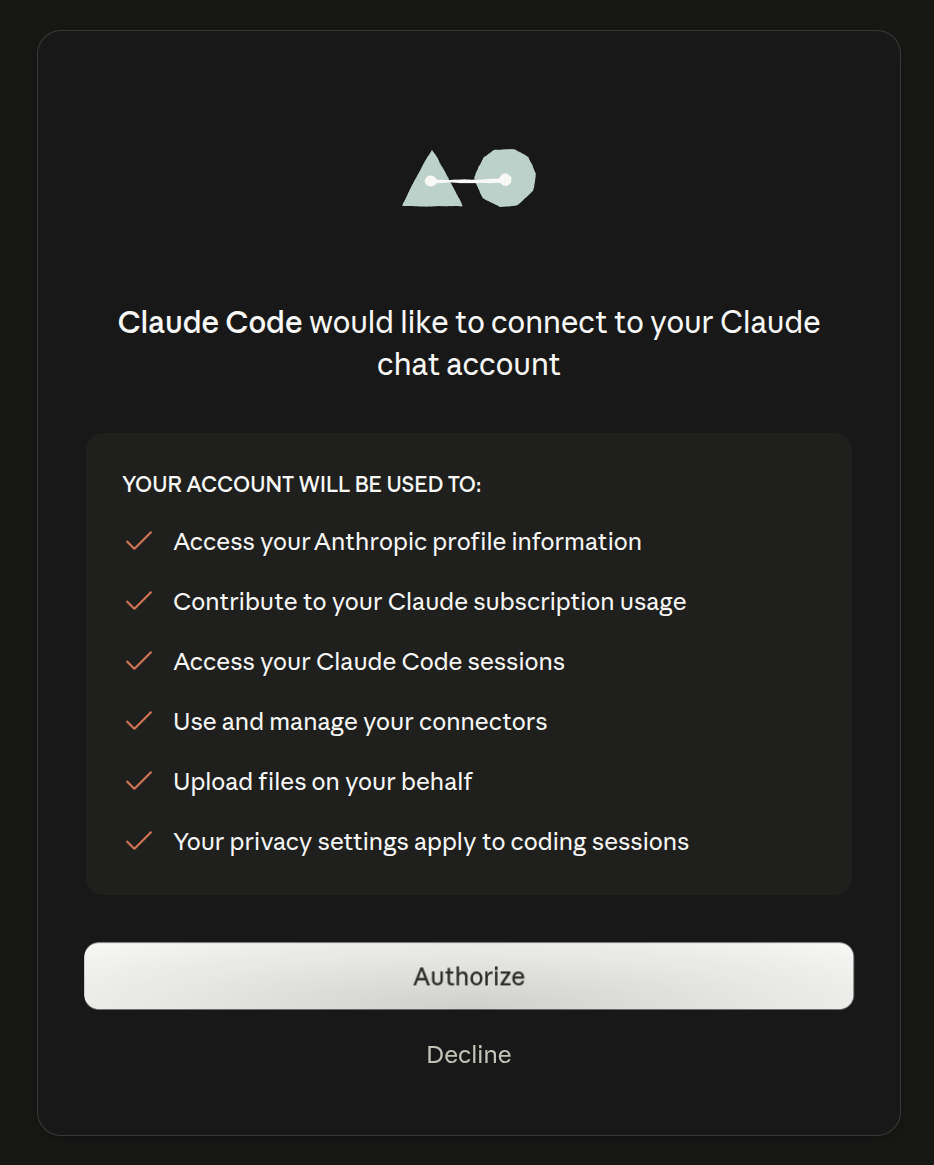

### One-shot Commands
```bash
claude "Explain what FAERS_Prep.ipynb does"          # Non-interactive
```
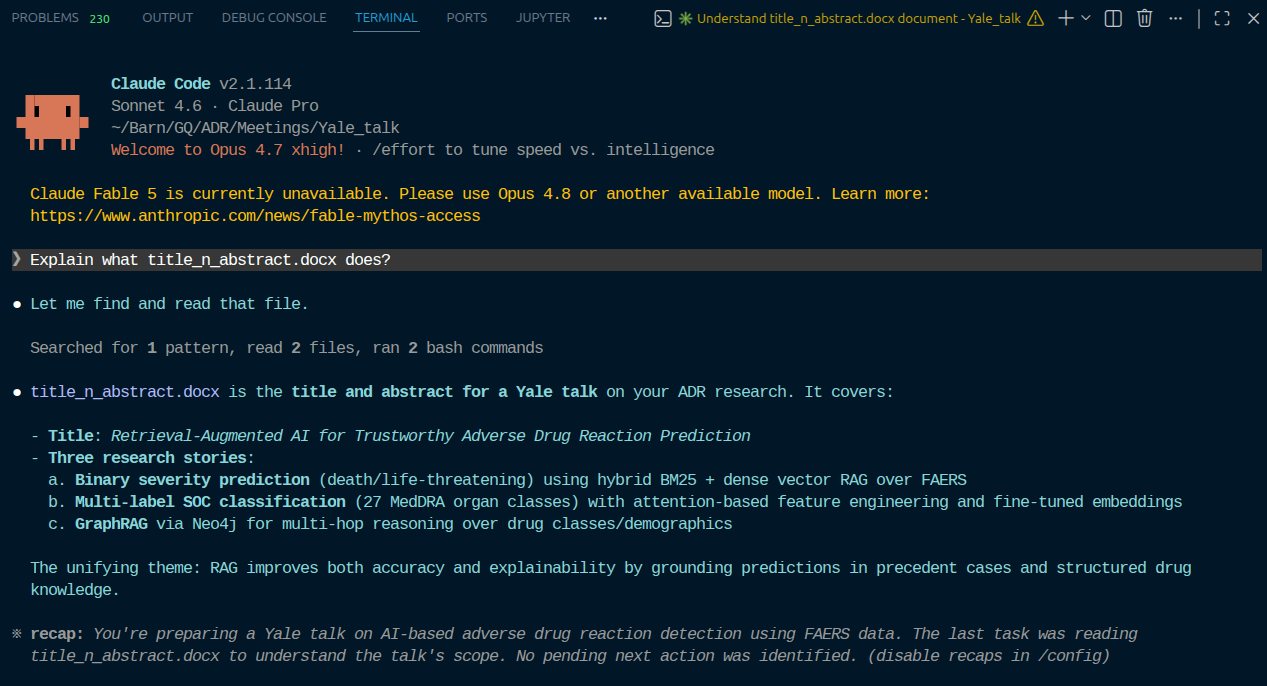

```bash
claude -p "Review this Python file" --file utils.py  # With file context
```



### Piping
```bash
cat adr_detection.py | claude "Find potential bugs"
git diff | claude "Write a commit message"
```

## 2.2 — Slash Commands Reference

| Command | What it does |
|---|---|
| `/help` | Show all available commands |
| `/clear` | Reset conversation context |
| `/compact` | Summarize and compress conversation |
| `/cost` | Show token usage and cost |
| `/model` | Switch models mid-session |
| `/fast` | Toggle Fast mode (Opus with faster output) |
| `/plan` | Enter planning mode — Claude presents a plan first |
| `/review` | Review code changes |
| `/mcp` | Manage MCP server connections |
| `/add-dir` | Add a directory to Claude's context |

### For Jupyter Research Workflows
```
/plan  → Review the plan before Claude touches any code
/cost  → Track API spending per session
/compact → Keep long research sessions alive without losing context
```

## 2.3 — VS Code Extension Workflow

### The Difference from GitHub Copilot

| Feature | GitHub Copilot | Claude Code |
|---|---|---|
| Scope | Current file | Entire repo |
| Tool use | Code completion only | Reads, writes, runs terminal |
| Context | Line-level | Project-level |
| Interaction | Inline completions | Conversational agent |

### Common VS Code Workflows
1. **Debug a failing test**: Open test output → ask Claude what's wrong
2. **Refactor a module**: "Refactor *your_code.py* to use pandas 2.0 API"
3. **Write documentation**: Select a function → "Document this with a docstring"
4. **Understand legacy code**: "Explain what this embedding pipeline does"
5. **Generate unit tests**: "Write pytest tests for the lookup_faers_reports function"

## 2.4 — MCP: Model Context Protocol

MCP lets Claude connect to **external data sources and tools** via a standard protocol.

### Configure `.mcp.json` in project path 
```json
{
  "mcpServers": {
    "faers_query": {
      "command": "/home/dada/anaconda3/bin/python",
      "args": ["/home/dada/Barn/GQ/ADR/Meetings/Yale_talk/utils/mcp_faers_server.py"]
    }
  }
}
```

Once connected, Claude can query FAERS query directly during a conversation — without any copy-paste!

### **utils/mcp_faers_server.py** — 3 tools for MCP server:
|Tool |OpenFDA call	| Use case|
|------|----------|---------|
|get_faers_count(drug)	|Total reports for a drug	|Quick signal triage|
|get_faers_top_events(drug, top_n)	|Top MedDRA PTs for a drug	|Adverse event profiling|
|get_faers_drug_event_pair(drug, event_pt)	|Co-report count	|PRR/ROR numerator|

###  use **Control+Shift+p** -> type "Developer: Reload Window" to refresh the notebook and see the cache in action.

### run **/mcp** in Claude chat
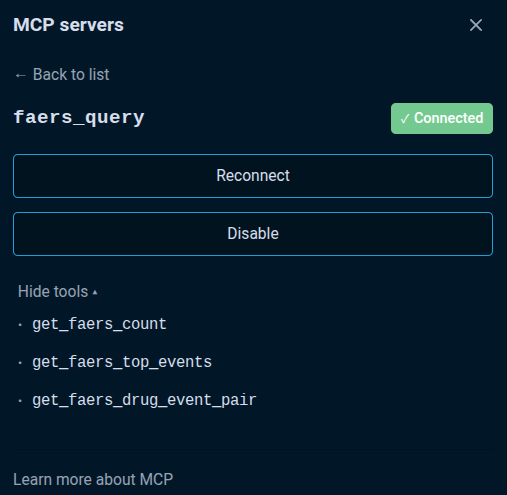

### run a test on MCP server tool in Claude chat
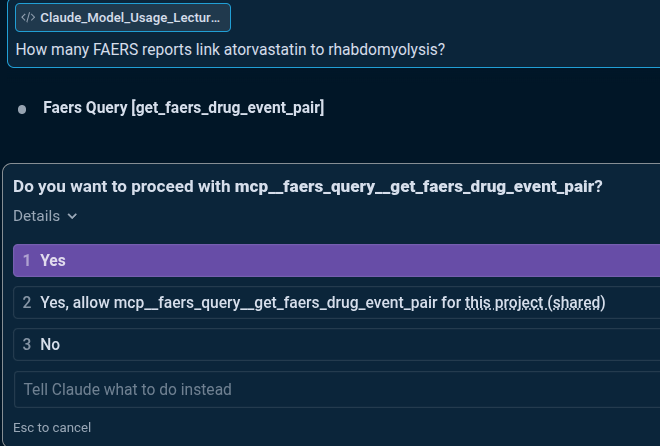




```
4,215 FAERS reports link atorvastatin to rhabdomyolysis.

This is the PRR/ROR numerator (a cell in the 2×2 table). To compute the full signal:

PRR = (4215 / total_atorvastatin_reports) ÷ (all_rhabdomyolysis_reports / all_reports)
Use get_faers_count("atorvastatin") for the denominator and a separate OpenFDA count query for background rhabdomyolysis rate
Want me to pull those numbers and compute the PRR?
```

## 3. Agnetic Solution for HIPAA & Data Privacy Considerations

### Before Using Claude with Patient Data

| Scenario | Status | What to do |
|---|---|---|
| De-identified research data (FAERS) | ✅ Generally OK | Standard API use |
| IRB-approved de-identified data | ✅ OK with BAA | Sign BAA with Anthropic |
| PHI (identified patient records) | ⚠️ Requires BAA | Enterprise API only |
| Clinical trial data with patient IDs | ❌ Without BAA | De-identify first |

### Safe Practices
1. **De-identify before sending**: Remove name, DOB, MRN, zip codes
2. **Use FAERS (already de-identified)**: Public dataset is safe
3. **Literature analysis**: Always safe — no patient data
4. **Enterprise plan + BAA**: Required for any PHI
5. **Zero data retention**: Available for sensitive workloads

> FAERS data you use for research is already de-identified under 21 CFR Part 314 — you can use it with the standard API.

## 3. Agentic Research Workflow

Combine everything into an end-to-end research agent:

```
Instruction : "Find the latest FAERS quarter, download it, and merge it into the Yale_talk folder."
    ↓
Agent Step 1: Web search for lastest data
    ↓
Agent Step 2: Upload file from online repo
    ↓
Agent Step 3: Process and integrate data w/ MCP tools
    ↓  
Agent Step 4: Output data to a path
```

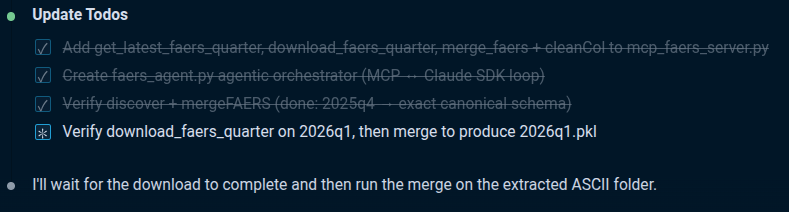

**Server-side tools** (no hosting required):
- `web_search` — find recent papers automatically
- `code_execution` — fetch, process, and output data

## 3.1 Build agentic orchestrator w/ MCP tools
The agentic orchestrator faers_agent.py 
 - launches the MCP server over stdio, 
 - converts its tools to the Anthropic Messages API schema, 
 - runs a Claude tool-use loop where Claude chooses the sequence:
   - discover → download → merge

### 3 new MCP tools added to mcp_faers_server.py (now 6 tools total):

|Tool	| Function|
|-------------| ----------|
|get_latest_faers_quarter()	|Probes FDA export URLs backward from today → finds latest release
|download_faers_quarter(year, quarter, dest_dir)	|Streams the ASCII zip, unzips, locates the ASCII folder (idempotent)
|`mergeFAERS(path_in, path_out)	|Merges DEMO/DRUG/OUTC/INDI/REAC → enriched 13-col pkl

## 3.2 — Choosing the Right Claude Model for Healthcare Tasks

| Task | Recommended Model | Why |
|---|---|---|
| Complex ADR reasoning, drug interactions | Opus 4.8 + `effort: "high"` | Deep clinical reasoning |
| Literature summarization | Opus 4.8 | Long documents, nuanced synthesis |
| MedDRA coding (bulk) | Haiku 4.5 | Fast, cheap, sufficient for structured tasks |
| Patient narrative extraction | Sonnet 4.6 | Balanced — good NLP, moderate cost |
| FAERS batch processing (100K+) | Haiku 4.5 (Batch API) | Maximum throughput at minimum cost |
| Research agent (multi-step) | Opus 4.8 | Complex planning and tool use |

### Cost Optimization Checklist
- ☑ Use Haiku for bulk classification (10× cheaper than Opus)
- ☑ Enable prompt caching for repeated drug knowledge bases (90% savings)
- ☑ Use Batch API for non-real-time processing (50% savings)
- ☑ Upload documents once via Files API (avoid re-uploading)
- ☑ Set `max_tokens` conservatively — you're charged for actual output

# Summary & Key Takeaways

## Prompting Ladder
```
Simple call → System prompt → Multi-turn → Thinking → Tools → Agents
```

## VS Code Integration
- `CLAUDE.md` = project memory (describe your data, conventions)
- `/plan` before touching code, `/cost` to monitor spend
- MCP connects Claude to your LanceDB / SQL databases

---
**Next steps:**
1. Install Claude Code: `npm install -g @anthropic-ai/claude-code`
2. Create `CLAUDE.md` in your ADR project directory
3. Try the agentic data processing pipeline on your next data update

## Resources & References

| Resource | URL |
|---|---|
| Anthropic API Docs | https://docs.anthropic.com |
| Python SDK | https://github.com/anthropic-ai/anthropic-sdk-python |
| Claude Code CLI | https://claude.ai/code |
| Model Pricing | https://anthropic.com/api/pricing |
| MedDRA Browser | https://www.meddra.org |
| FAERS Data | https://fis.fda.gov/extensions/FPD-QDE-FAERS |

### Install for this lecture
```bash
pip install anthropic>=0.40.0
npm install -g @anthropic-ai/claude-code
export ANTHROPIC_API_KEY="sk-ant-..."
```